## Importing Necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Converting csv into DataFrame

In [2]:
df = pd.read_csv('netflix_titles.csv')

### Inspection of Dataset

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# shape of the dataset
df.shape

(8807, 12)

In [5]:
# displaying the columns of the dataset
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


## Data Cleaning

### 1. Handling Duplicated values

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

In [8]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


### 2. Handling Missing values

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})
missing_report.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
release_year,0,0.000000


In [11]:
# 1. director - 2634
df['director'].unique()

<ArrowStringArray>
[              'Kirsten Johnson',                             nan,
               'Julien Leclercq',                 'Mike Flanagan',
 'Robert Cullen, José Luis Ucha',                  'Haile Gerima',
               'Andy Devonshire',                'Theodore Melfi',
             'Kongkiat Komesiri',           'Christian Schwochow',
 ...
       'Saratswadee Wongsomphet',             'Kirati Nakintanon',
                   'Mark Risley',                   'James Brown',
                    'Ivona Juka',                        'Mu Chu',
       'Chandra Prakash Dwivedi',               'Majid Al Ansari',
                  'Peter Hewitt',                   'Mozez Singh']
Length: 4529, dtype: str

In [12]:
# filling 'director' column nan values to 'unknown'
df['director'] = df['director'].fillna('unknown')

In [13]:
# fiiling 'cast' column nan values to Not Available

df['cast'] = df['cast'].fillna('Not Available')

In [14]:
# fiiling 'country' column nan values to Not Available

df['country'] = df['country'].fillna('unknown')

#### Rating Column 

In [15]:
df['rating'].unique()

<ArrowStringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',        nan, 'TV-Y7-FV',       'UR']
Length: 18, dtype: str

#### Report : The issue is 74 min, 84 min are belong in the duration column 

In [16]:
df[df['rating'].str.contains('min',na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [17]:
mask = df['rating'].str.contains('min',na=False)
df.loc[mask,'duration'] = df.loc[mask,'rating']

In [18]:
# optionally setting rating as missing
df.loc[mask,'rating']=np.nan

In [19]:
df['rating'] = df['rating'].fillna('unknown')

In [20]:
# checking the rating column
df['rating'].unique()

<ArrowStringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',  'unknown',
       'NR', 'TV-Y7-FV',       'UR']
Length: 15, dtype: str

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [22]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [23]:
# report : date_added column can be handled during the change of datatype

### 3. Identifying Column Datatype & convert Data Types

In [24]:
categorical_col =  df.select_dtypes(include=['string','object']).columns
numerical_col = df.select_dtypes(include=['number']).columns

print('Categorical Columns :', categorical_col)
print('Numerical Columns :', numerical_col)

Categorical Columns : Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
Numerical Columns : Index(['release_year'], dtype='str')


#### RESULT : 
* The duration column is under CATEGORICAL COLUMN . so we need to change it
* Movies - 90 mins ; Tv shows - 1 season , 3 seasons

In [25]:
# step 1 : check unique values

df['duration'].unique()

<ArrowStringArray>
[   '90 min', '2 Seasons',  '1 Season',    '91 min',   '125 min', '9 Seasons',
   '104 min',   '127 min', '4 Seasons',    '67 min',
 ...
    '43 min',   '200 min',   '196 min',   '167 min',   '178 min',   '228 min',
    '18 min',   '205 min',   '201 min',   '191 min']
Length: 220, dtype: str

In [26]:
# step 2 : separate Movie and Tv Show Duration

movie_duration = df[df['type'] == 'Movie']['duration']

In [27]:
df['duration_int'] = df['duration'].str.extract('(\d+)')
df['duration_type'] = df['duration'].str.extract('([A-Za-z]+)')

In [28]:
df['duration_int'] = df['duration_int'].astype('float')

In [29]:
# checking after conversion

df[['duration','duration_int','duration_type']].head()

,duration,duration_int,duration_type
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons


### `Date_added` column
* original format : Septmeber 25,2021

In [30]:
df['date_added'].dtype

<StringDtype(na_value=nan)>

In [31]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [32]:
df['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[us]

In [33]:
df.sample(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,duration_type
4877,s4878,Movie,End Game,"Rob Epstein, Jeffrey Friedman",Not Available,United States,2018-05-04,2018,TV-PG,40 min,Documentaries,"Facing an inevitable outcome, terminally ill p...",40.0,min
7261,s7262,Movie,Lady Bloodfight,Chris Nahon,"Amy Johnston, Muriel Hofmann, Jenny Wu, Kathy ...",Hong Kong,2017-08-05,2016,R,101 min,Action & Adventure,An American travels to Hong Kong in hopes of w...,101.0,min
2224,s2225,Movie,Funan,Denis Do,"Bérénice Bejo, Louis Garrel, Colette Kieffer, ...","France, Belgium, Luxembourg, Cambodia,",2020-07-18,2018,TV-14,87 min,"Dramas, International Movies",Separated from their young son during the brut...,87.0,min
3083,s3084,TV Show,Pucca: Love Recipe,unknown,"Jeonghwa Yang, Yongwoo Shin, Doug Erholtz, Mel...",unknown,2019-12-31,2018,TV-Y7,1 Season,"Kids' TV, Korean TV Shows",Faced with a threat to the survival of her fam...,1.0,Season
7914,s7915,Movie,Sacro GRA,Gianfranco Rosi,Not Available,"Italy, France",2017-03-21,2013,TV-MA,91 min,"Documentaries, International Movies",Italian filmmaker Gianfranco Rosi turns his ey...,91.0,min
1989,s1990,TV Show,Baby,unknown,"Benedetta Porcaroli, Alice Pagani, Riccardo Ma...",Italy,2020-09-16,2020,TV-MA,3 Seasons,"International TV Shows, TV Dramas, Teen TV Shows","Fed up with their families and classmates, two...",3.0,Seasons
2441,s2442,Movie,What's Up?,Izidore K. Musallam,"Hisham Abdulrahman, Turki Al-Yusuf, Mais Hamda...","Saudi Arabia, United Arab Emirates",2020-06-02,2006,TV-PG,95 min,"Comedies, Dramas, International Movies","Flirting with modernity, a young woman must ke...",95.0,min
4302,s4303,Movie,Sad Hill Unearthed,Guillermo de Oliveira,Not Available,Spain,2018-12-15,2017,TV-14,83 min,"Documentaries, International Movies","An eclectic group of fans of 1966's ""The Good,...",83.0,min
2497,s2498,Movie,I Will Follow,Ava DuVernay,"Salli Richardson-Whitfield, Michole Briana Whi...",United States,2020-05-20,2010,TV-14,80 min,"Dramas, Independent Movies, Romantic Movies","Devastated after her aunt dies, Maye moves out...",80.0,min
5491,s5492,Movie,Sahara,Pierre Coré,"Robert Naylor, Angela Galuppo, Daniel Brochu, ...","France, Canada",2017-05-12,2017,TV-Y7,86 min,Children & Family Movies,When his new love is captured by an evil snake...,86.0,min


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   str           
 1   type           8807 non-null   str           
 2   title          8807 non-null   str           
 3   director       8807 non-null   str           
 4   cast           8807 non-null   str           
 5   country        8807 non-null   str           
 6   date_added     8709 non-null   datetime64[us]
 7   release_year   8807 non-null   int64         
 8   rating         8807 non-null   str           
 9   duration       8807 non-null   str           
 10  listed_in      8807 non-null   str           
 11  description    8807 non-null   str           
 12  duration_int   8807 non-null   float64       
 13  duration_type  8807 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(11)
memory usage: 3.9 MB


In [35]:
# creating year , month , date in separate column

df['year_added'] = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month_name()

In [36]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,duration_type,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,2021,September
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons,2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,2021,September
3,s4,TV Show,Jailbirds New Orleans,unknown,Not Available,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021,September
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons,2021,September


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   str           
 1   type           8807 non-null   str           
 2   title          8807 non-null   str           
 3   director       8807 non-null   str           
 4   cast           8807 non-null   str           
 5   country        8807 non-null   str           
 6   date_added     8709 non-null   datetime64[us]
 7   release_year   8807 non-null   int64         
 8   rating         8807 non-null   str           
 9   duration       8807 non-null   str           
 10  listed_in      8807 non-null   str           
 11  description    8807 non-null   str           
 12  duration_int   8807 non-null   float64       
 13  duration_type  8807 non-null   str           
 14  year_added     8709 non-null   Int64         
 15  month_added    8709 non-null   s

In [38]:
# cross the missing values
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       98
release_year      0
rating            0
duration          0
listed_in         0
description       0
duration_int      0
duration_type     0
year_added       98
month_added      98
dtype: int64

### 4. clean text columns

In [39]:
# 1. cleaning `title`
df['title'] = df['title'].str.strip()

In [40]:
# 2. cleaning 'cast'
df['cast']

0                                           Not Available
1       Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2       Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                           Not Available
4       Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
                              ...                        
8802    Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...
8803                                        Not Available
8804    Jesse Eisenberg, Woody Harrelson, Emma Stone, ...
8805    Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...
8806    Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...
Name: cast, Length: 8807, dtype: str

In [41]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,duration_type,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,2021,September
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Seasons,2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,2021,September
3,s4,TV Show,Jailbirds New Orleans,unknown,Not Available,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021,September
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Seasons,2021,September


In [42]:
# if we want actor level analysis

df['cast'] = df['cast'].str.split(',')

# it becomes
# ['Mark Ruffalo', ' Jake Gyllenhaal', ' Robert Downey Jr.']

In [43]:
# so spaces still exist before names
df['cast'] = df['cast'].apply(
    lambda x : [i.strip() for i in x]
)

In [44]:
type(df['cast'][0])

list

In [45]:
# Clean the listed_in column

df['listed_in'] = df['listed_in'].str.split(',')

In [46]:
# convert to list for removing the strip

df['listed_in'] = df['listed_in'].apply(
    lambda x : [i.strip() for i in x]
)

In [47]:
# clean the country - there is a multiple countries in a single value

df['country'] = df['country'].str.split(',')
df['country'] = df['country'].apply(
    lambda x : [i.strip() for i in x]
)

In [48]:
# striping the Description

df['description'] = df['description'].str.strip()

In [49]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,duration_type,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,[Not Available],[United States],2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",90.0,min,2021,September
1,s2,TV Show,Blood & Water,unknown,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",2.0,Seasons,2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[unknown],2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,1.0,Season,2021,September
3,s4,TV Show,Jailbirds New Orleans,unknown,[Not Available],[unknown],2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021,September
4,s5,TV Show,Kota Factory,unknown,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[India],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,2.0,Seasons,2021,September


### REPORT of Data Cleaning

* Missing values columns - director , cast , country , date_added, rating, duration `Handled`

* duplicates - `Dataset doesn't contains duplicates`

* Column Data type Mismatched - date_added , duration `Converted`

* cleaning text - `stripped`

# Analysis + Visulaization

## Analytical Questions 

### Distribution Analysis
1. What is the distribution of Movies and TV Shows on Netflix?
2. Which genres are most common on Netflix?
3. Which content ratings appear most frequently?
4. Which countries contribute the most Netflix content?

In [50]:
# Distribution of Movies vs TV Shows

movies_tv_dist = df['type'].value_counts()

dist_percentage = round((movies_tv_dist / len(df)) * 100,2)

dist_mtv = pd.DataFrame({
    'Distribution': movies_tv_dist,
    'Percentage': dist_percentage
})

dist_mtv.sort_values(by='Percentage', ascending=False)

,Distribution,Percentage
type,,
Movie,6131,69.62
TV Show,2676,30.38


#### Visualization

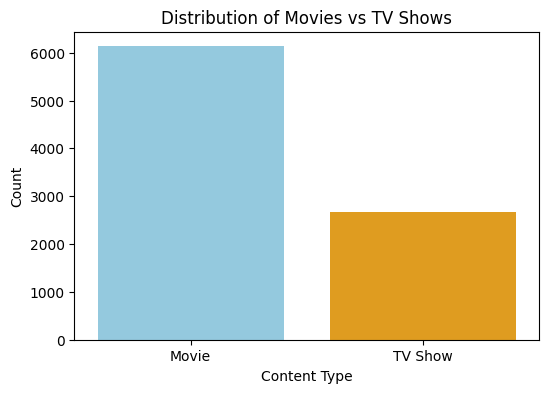

In [51]:
# 1. create figure
plt.figure(figsize=(6,4))

# 2. visulaize result dataframe
sns.barplot(
    x=dist_mtv.index,
    y=dist_mtv['Distribution'],
    hue=dist_mtv.index,
    palette=['skyblue','orange'],
    legend=False
)

# 3. Title
plt.title('Distribution of Movies vs TV Shows')

# 4.Axis Labels
plt.xlabel('Content Type')
plt.ylabel('Count')

# 5. Show chart
plt.show()

#### Insights
**Movies dominate Netflix’s catalog, indicating that Netflix focuses more heavily on movie content than TV shows.**

In [52]:
# 2. Which genres are most common on Netflix?

# explode
genre_df = df.explode('listed_in')

# counts
genre_counts = genre_df['listed_in'].value_counts()

genre_percentage = round(genre_counts / len(genre_df) * 100,2)

genre_distribution = pd.DataFrame({
    'Count' : genre_counts,
    'Percentage' : genre_percentage
})

genre_distribution.sort_values(by = 'Percentage', ascending=False)

,Count,Percentage
listed_in,,
International Movies,2752,14.24
Dramas,2427,12.56
Comedies,1674,8.66
International TV Shows,1351,6.99
Documentaries,869,4.50
Action & Adventure,859,4.45
TV Dramas,763,3.95
Independent Movies,756,3.91
Children & Family Movies,641,3.32


#### Visualization

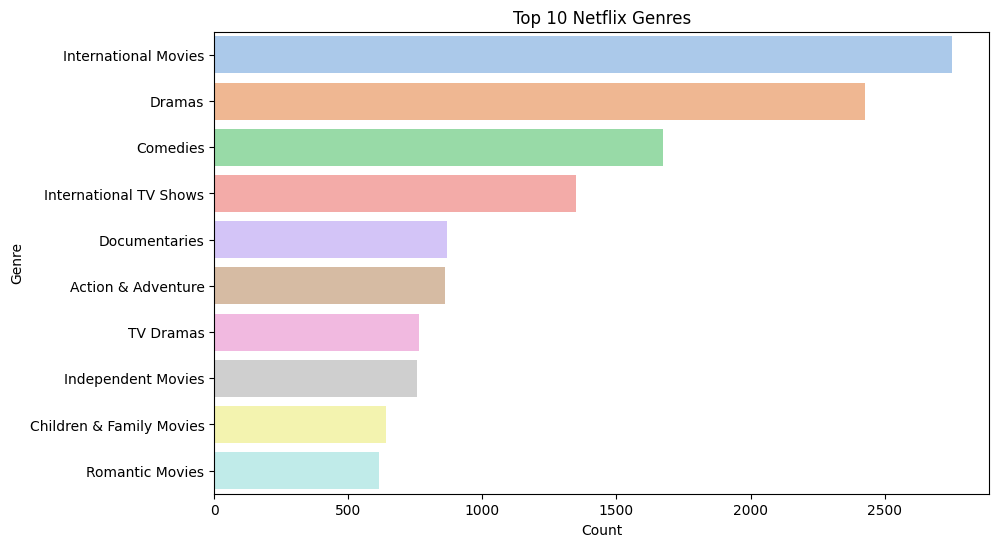

In [53]:
# Visualization

# Select top 10 genres
top_genres = genre_distribution.head(10)

# Create figure
plt.figure(figsize=(10,6))

# Horizontal bar chart
sns.barplot(
    y=top_genres.index,
    x=top_genres['Count'],
    hue=top_genres.index,
    palette='pastel',
    legend=False
)

# Title and labels
plt.title('Top 10 Netflix Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

# Show chart
plt.show()

#### Insights

**International Movies and Dramas are the most common genres on Netflix, suggesting a strong focus on globally diverse entertainment content.**

In [54]:
# Which content ratings appear most frequently?

rating_count = df['rating'].value_counts()
rating_percentage = round(rating_count / len(df['rating'])*100,2)

rating_distribution = pd.DataFrame({
    'Count':rating_count,
    'Percentage':rating_percentage
})

rating_distribution

,Count,Percentage
rating,,
TV-MA,3207,36.41
TV-14,2160,24.53
TV-PG,863,9.80
R,799,9.07
PG-13,490,5.56
TV-Y7,334,3.79
TV-Y,307,3.49
PG,287,3.26
TV-G,220,2.50


#### Visualization

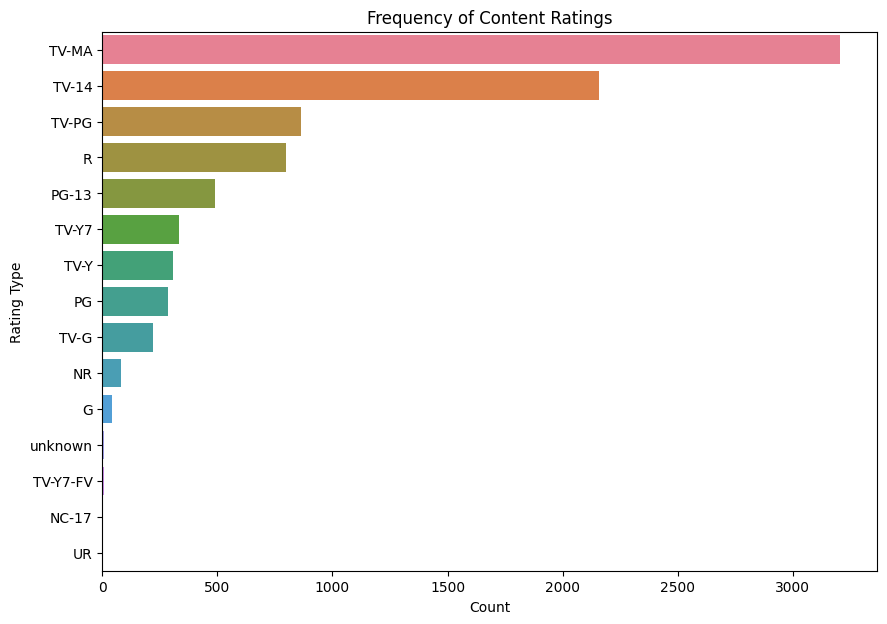

In [55]:
plt.figure(figsize=(10,7))

sns.barplot(
    y=rating_distribution.index,
    x=rating_distribution['Count'],
    hue=rating_distribution.index,
    palette = sns.color_palette(
        'husl',
        len(rating_distribution.index)
    ),
    legend=False
)

plt.title('Frequency of Content Ratings')

plt.xlabel('Count')
plt.ylabel('Rating Type')

plt.show()

#### Insights

**TV-MA and TV-14 content ratings are most frequently appeared on Netflix Catalog. suggesting that Netflix primarily targets mature and teenage audiences**

In [56]:
# Which countries contribute the most Netflix content?

country_df = df.explode('country')
country_df = country_df[country_df['country'] != 'unknown']
country_count = country_df['country'].value_counts()
country_percentage = round(country_count / len(country_df)*100,2)

country_distribution = pd.DataFrame({
    'Count' : country_count,
    'Percentage' : country_percentage
})

country_distribution.sort_values(by='Percentage',ascending=False)

,Count,Percentage
country,,
United States,3690,36.83
India,1046,10.44
United Kingdom,806,8.04
Canada,445,4.44
France,393,3.92
...,...,...
Sudan,1,0.01
Panama,1,0.01
Uganda,1,0.01


#### Visualize

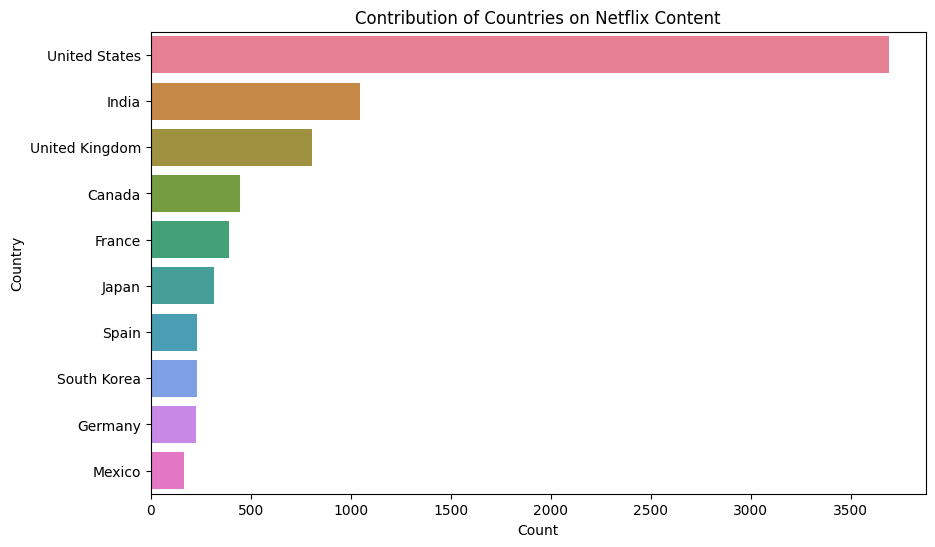

In [57]:
# showing top 10
top_countries = country_distribution.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    y=top_countries.index,
    x=top_countries['Count'],
    hue=top_countries.index,
    palette = sns.color_palette(
        'husl',
        len(top_countries.index)
    ),
    legend=False
)

plt.title('Contribution of Countries on Netflix Content')

plt.xlabel('Count')
plt.ylabel('Country')

plt.show()

#### Insights

**The dominance of the United States and India suggests that Netflix focuses strongly on content from large entertainment markets.**

---

### Trend Analysis
1. How has Netflix content grown over time?
2. How have Movies and TV Shows changed over time?
3. Which genres have become more popular over the years?
4. Which years saw the highest number of titles added to Netflix?

In [58]:
# 1. How has Netflix content grown over time?

content_growth = df['year_added'].value_counts().sort_index()

growth_df = pd.DataFrame({
    'Year' : content_growth.index,
    'Titles Added': content_growth.values
})

growth_df

,Year,Titles Added
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,10
6,2014,23
7,2015,73
8,2016,418
9,2017,1164


#### Visualization

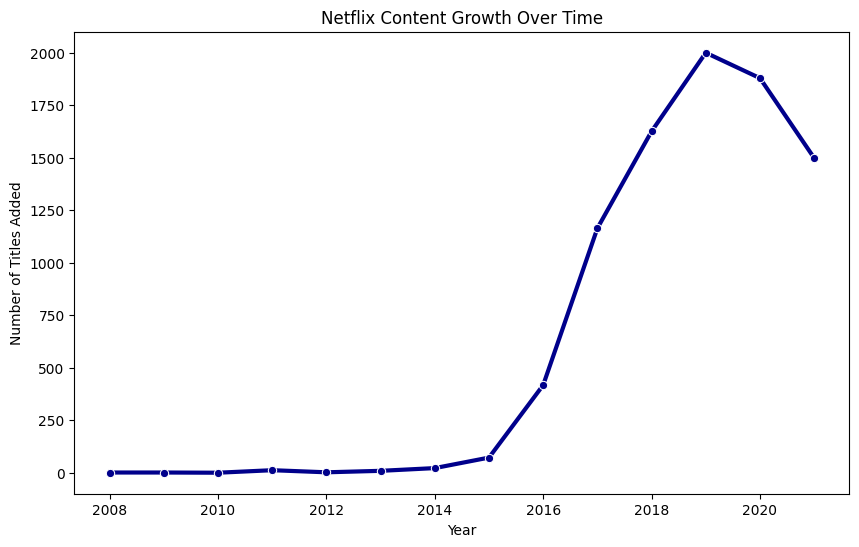

In [59]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=growth_df['Year'],
    y=growth_df['Titles Added'],
    marker='o',
    color='darkblue',
    linewidth=3
)

plt.title('Netflix Content Growth Over Time')

plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.show()

#### Insights

**After 2016, the Netflix content grew tremendously. suggesting that the platform aggressively expanded its cobtent library to attract audience**

In [60]:
# 2. How have Movies and TV Shows changed over time?

movie_growth = df[df['type'] == 'Movie']['year_added'].value_counts().sort_index()
tv_show_growth = df[df['type'] == 'TV Show']['year_added'].value_counts().sort_index()


type_trends = pd.concat([movie_growth,tv_show_growth],axis=1)
# Rename columns
type_trends.columns = ['Movies', 'TV Shows']

# Fill missing values
type_trends = type_trends.fillna(0)
type_trends

,Movies,TV Shows
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,4
2014,19,4
2015,56,17
2016,253,165


#### Visualization

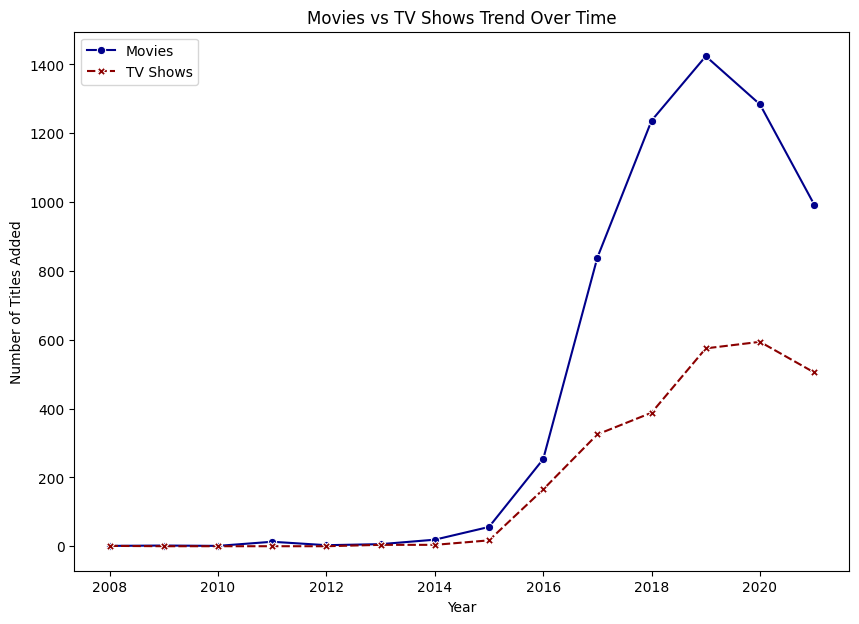

In [61]:
plt.figure(figsize=(10,7))

sns.lineplot(
    data=type_trends,
    markers=True,
    dashes=True,
    palette=['darkblue', 'darkred']
)

plt.title('Movies vs TV Shows Trend Over Time')

plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.legend()

plt.show()

#### Insights

**Netflix content additions increased rapidly after 2015 for both Movies and TV Shows. However, Movies remained substantially higher than TV Shows, indicating Netflix's stronger focus on movie content.**

In [62]:
# 3. Which genres have become more popular over the years?

# 1. Explode genres
exploded_genre_df = df.explode('listed_in')

# 2. Group by year and genre
genre_trends = exploded_genre_df.groupby(
    ['year_added','listed_in']
).size().reset_index(name='count')

genre_trends

,year_added,listed_in,count
0,2008,Dramas,1
1,2008,Independent Movies,1
2,2008,Stand-Up Comedy & Talk Shows,1
3,2008,Thrillers,1
4,2009,Dramas,1
...,...,...,...
321,2021,TV Sci-Fi & Fantasy,20
322,2021,TV Shows,5
323,2021,TV Thrillers,13
324,2021,Teen TV Shows,18


In [63]:
# because 326 rows is hard to interpret manually
top_genres = exploded_genre_df['listed_in'].value_counts().head(5).index

top_genre_trends = genre_trends[genre_trends['listed_in'].isin(top_genres)]
top_genre_trends

,year_added,listed_in,count
0,2008,Dramas,1
4,2009,Dramas,1
6,2009,International Movies,1
10,2011,Dramas,13
12,2011,International Movies,1
16,2012,Comedies,2
17,2012,Documentaries,1
19,2013,Comedies,1
21,2013,Documentaries,1
23,2013,International TV Shows,1


#### Visualization

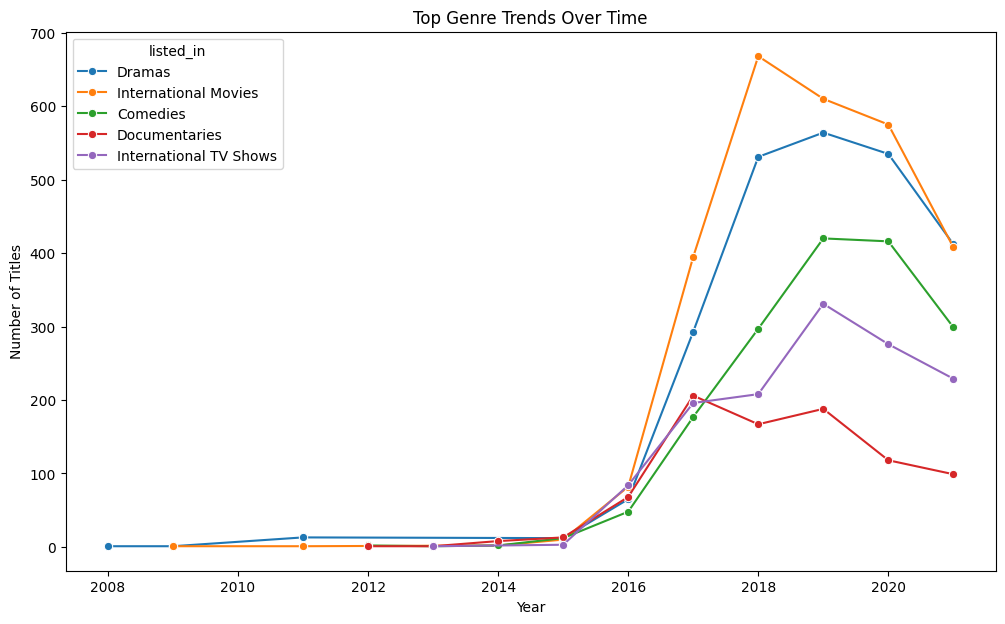

In [64]:
# visualization

plt.figure(figsize=(12,7))

sns.lineplot(
    data = top_genre_trends,
    x='year_added',
    y='count',
    hue='listed_in',
    marker='o'
)

plt.title('Top Genre Trends Over Time')

plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

#### Insights

**Netflix experienced substantial growth in genre diversity after 2016, particularly in Dramas and International Movies, suggesting aggressive global content expansion.**

In [65]:
# 4.Which years saw the highest number of titles added to Netflix?

titles_per_year = df.groupby('year_added').size().reset_index(name='Titles Added')
titles_per_year = titles_per_year.sort_values(by='Titles Added',ascending=False)
titles_per_year

,year_added,Titles Added
11,2019,1999
12,2020,1878
10,2018,1625
13,2021,1498
9,2017,1164
8,2016,418
7,2015,73
6,2014,23
3,2011,13
5,2013,10


#### Visualization

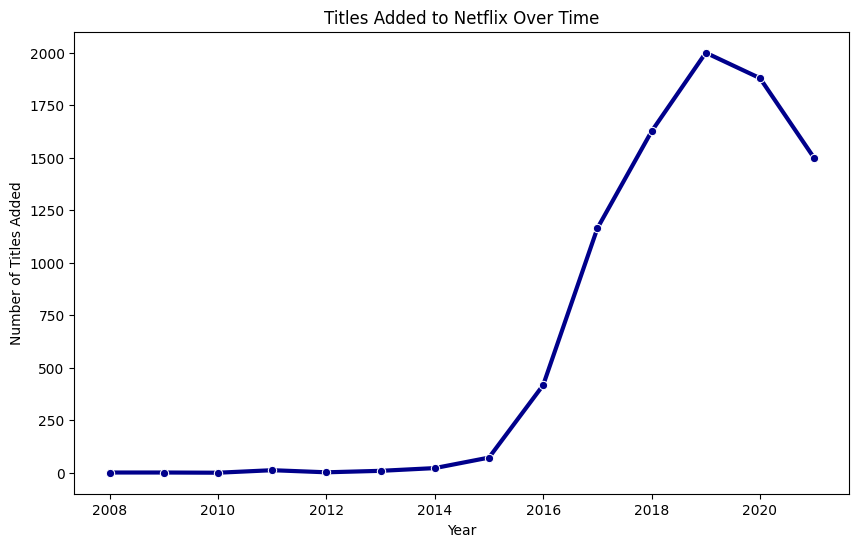

In [66]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=titles_per_year,
    x='year_added',
    y='Titles Added',
    marker='o',
    color='darkblue',
    linewidth=3
)

plt.title('Titles Added to Netflix Over Time')

plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.show()

#### Insights

**Netflix experienced a sharp rise in content additions after 2015, with peak additions occurring around 2019, indicating rapid platform expansion during that period.**

---

### Comparison Analysis
1. Which countries produce more TV Shows than Movies?
2. How do genre distributions differ between Movies and TV Shows?
3. Do Movies and TV Shows have different rating distributions?

In [67]:
# Which countries produce more TV Shows than Movies?

# 1. explode the country
country_df = df.explode('country')

# 2. using group by countries and types
country_compare = country_df.groupby(['country','type']).size().reset_index(name='count')

# 3. Pivot table
country_compare = country_compare.pivot(
    index = 'country',
    columns = 'type',
    values='count'
)

# 4. Find countries with more Tv shows
tvshow_countries = country_compare[country_compare['TV Show'] > country_compare['Movie']]

# sort by TV Shows
tvshow_countries = tvshow_countries.sort_values(
    by='TV Show',
    ascending=False
)

# Top 10 countries
top_tvshow_countries = tvshow_countries.head(10)
top_tvshow_countries

type,Movie,TV Show
country,,
Japan,119.0,199.0
South Korea,61.0,170.0
Taiwan,19.0,70.0
Colombia,20.0,32.0
Singapore,18.0,23.0
Russia,11.0,16.0
Ukraine,1.0,2.0


#### Visualization

<Figure size 1200x700 with 0 Axes>

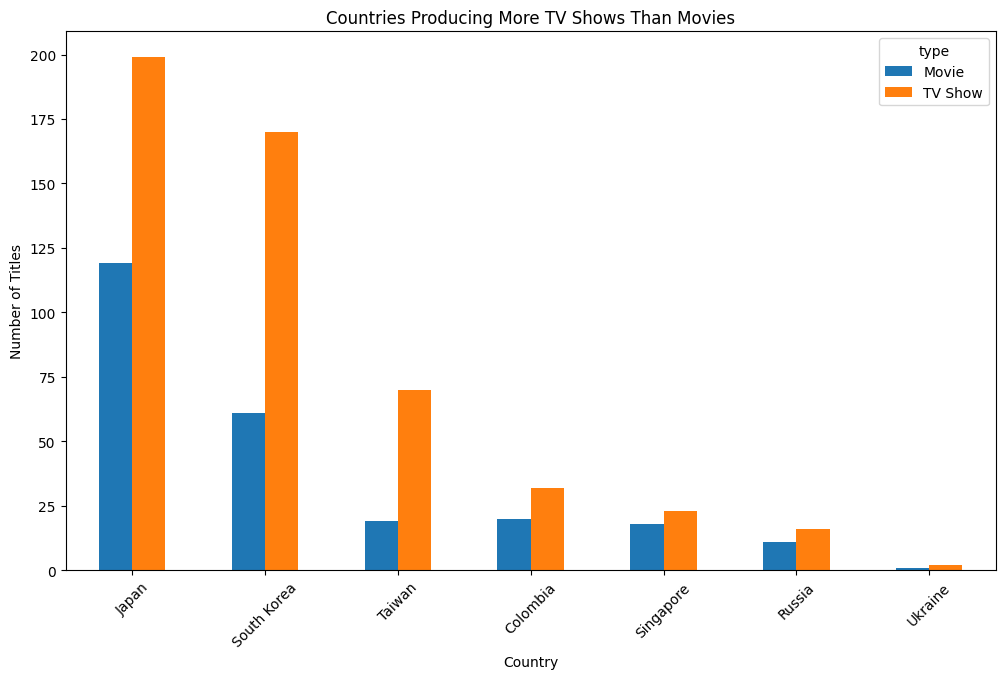

In [68]:
plt.figure(figsize=(12,7))

# Grouped Bar chart
top_tvshow_countries.plot(
    kind='bar',
    figsize=(12,7)
)

# Title
plt.title('Countries Producing More TV Shows Than Movies')

plt.xlabel('Country')
plt.ylabel('Number of Titles')

# Rotate labels
plt.xticks(rotation=45)

plt.show()

#### Insights

**Certain countries, particularly in Asia, contribute more TV Shows than Movies, suggesting stronger audience demand for serialized entertainment content in those regions.**

In [69]:
# How do genre distributions differ between Movies and TV Shows?

# 1. explode the 'listed_in' column
genre_df = df.explode('listed_in')

# 2. groupby Genres and types
genre_compare = genre_df.groupby(['listed_in','type']).size().reset_index(name='count')

# 3. pivot
genre_compare = genre_compare.pivot(
    index = 'listed_in',
    columns = 'type',
    values='count'
)

# 4. Fill missing values
genre_compare = genre_compare.fillna(0)


# Find top 10 genres
top_genres = genre_compare[
    ['Movie', 'TV Show']
].sum(axis=1).sort_values(
    ascending=False
).head(10).index

# Filter DataFrame
top_genre_compare = genre_compare.loc[top_genres]

top_genre_compare

type,Movie,TV Show
listed_in,,
International Movies,2752.0,0.0
Dramas,2427.0,0.0
Comedies,1674.0,0.0
International TV Shows,0.0,1351.0
Documentaries,869.0,0.0
Action & Adventure,859.0,0.0
TV Dramas,0.0,763.0
Independent Movies,756.0,0.0
Children & Family Movies,641.0,0.0


#### Visualization

<Figure size 1200x700 with 0 Axes>

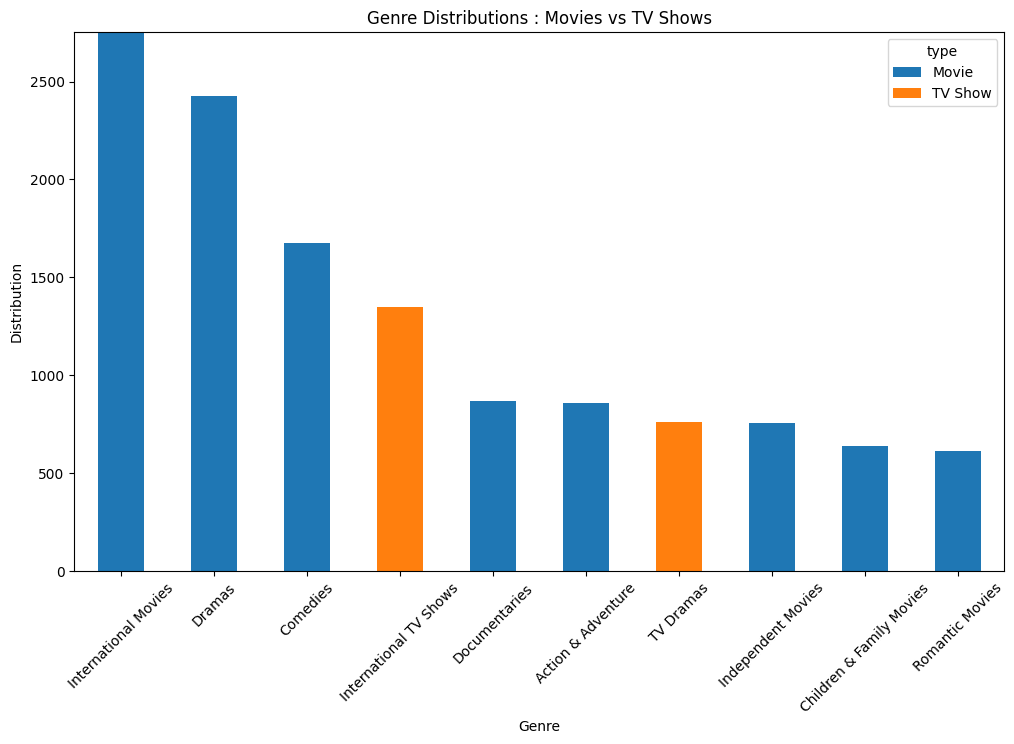

In [70]:
plt.figure(figsize=(12,7))

# Grouped Bar Chart
top_genre_compare.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

# Title
plt.title('Genre Distributions : Movies vs TV Shows')

plt.xlabel('Genre')
plt.ylabel('Distribution')

# Rotate labels
plt.xticks(rotation=45)

plt.show()

#### Insights

**Movies dominate most genres on Netflix, while TV Shows are concentrated in fewer categories such as TV Dramas and International TV Shows. This suggests Netflix maintains broader genre diversity in Movies compared to TV Shows.**

In [71]:
# 3. Do Movies and TV Shows have different rating distributions?

# 1. Grouping the rating and type columns
rating_comparison = df.groupby(['rating','type']).size().reset_index(name='count')

# 2. pivot table for better comparison
rating_comparison = rating_comparison.pivot(
    index = 'rating',
    columns = 'type',
    values = 'count'
)

rating_comparison = rating_comparison.fillna(0)

# Convert to integer
rating_comparison = rating_comparison.astype(int)

rating_comparison

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94
TV-MA,2062,1145


#### Visualization

<Figure size 1200x700 with 0 Axes>

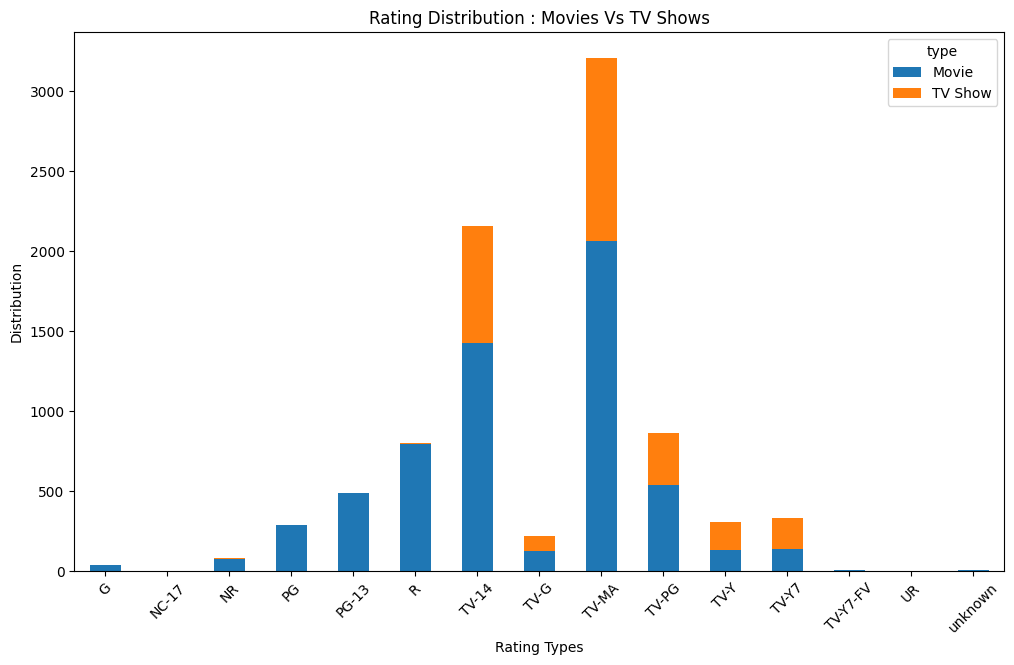

In [72]:
plt.figure(figsize=(12,7))


# 2. Grouped Bar Chart
rating_comparison.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

plt.title('Rating Distribution : Movies Vs TV Shows')

plt.xlabel('Rating Types')
plt.ylabel('Distribution')

plt.xticks(rotation=45)

plt.show()

#### Insights

**TV-MA and TV-14 ratings dominate both Movies and TV Shows. However, TV Shows contain relatively higher counts in these ratings, suggesting Netflix prioritizes mature audience engagement through episodic content.**

---

### Relationship Analysis
1. Do certain directors focus on specific genres?
2. Are longer movies associated with specific ratings?
3. Do different countries prefer different genres?

In [73]:
# 1. Do certain directors focus on specific genres?

# Explode the listed_in
exploded_df = df.explode('listed_in')

# Eliminating the unknowns
director_df = exploded_df[exploded_df['director'] != 'Unknown']

# groupby genre and director
genre_director = director_df.groupby(['director','listed_in']).size().reset_index(name='count')

# 4. pivot 
genre_director = genre_director.pivot(
    index = 'director',
    columns = 'listed_in',
    values = 'count'
)

# 5. Fill missing values
genre_director = genre_director.fillna(0)

# 6. Convert float to integer
genre_director = genre_director.astype(int)

# 7. Find dominant genre for each director
director_focus = genre_director.idxmax(axis=1)

# 8. Convert into dataframe
director_focus = director_focus.reset_index(name='Primary Genre')

# 9. Show result
director_focus.head(20)

,director,Primary Genre
0,A. L. Vijay,Comedies
1,A. Raajdheep,Dramas
2,A. Salaam,Action & Adventure
3,A.R. Murugadoss,Action & Adventure
4,Aadish Keluskar,Dramas
5,Aamir Bashir,Dramas
6,Aamir Khan,Dramas
7,Aanand Rai,Comedies
8,Aaron Burns,International Movies
9,"Aaron Hancox, Michael McNamara",Documentaries


#### Visualization

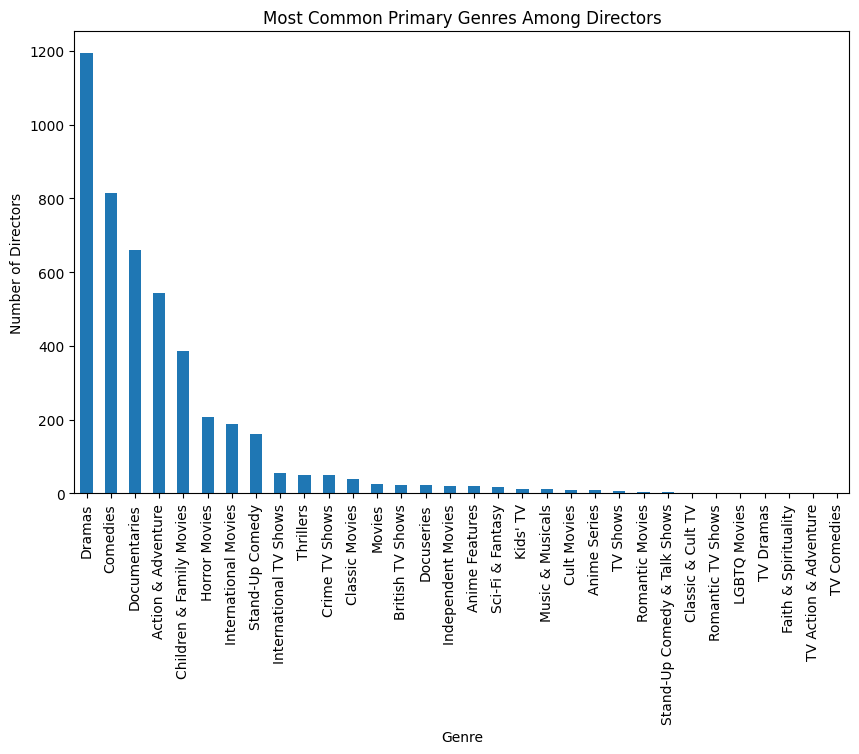

In [74]:
director_focus['Primary Genre'].value_counts().plot(
    kind = 'bar',
    figsize=(10,6)
)

plt.title('Most Common Primary Genres Among Directors')

plt.xlabel('Genre')
plt.ylabel('Number of Directors')

plt.show()

#### Insights

**Certain directors focus more on Drama genres, meaning directors usually create content in cetagories where they have more experience and popularity.**

In [75]:
# Are longer movies associated with specific ratings?

movie_df = df[df['type'] == 'Movie']

rating_duration = movie_df.groupby('rating')['duration_int'].mean().reset_index()

rating_duration = rating_duration.sort_values(by='duration_int', ascending=False)
rating_duration

,rating,duration_int
1,NC-17,125.000000
6,TV-14,110.290820
4,PG-13,108.330612
5,R,106.720201
13,UR,106.333333
3,PG,98.282230
8,TV-MA,95.889913
9,TV-PG,94.851852
2,NR,94.533333
0,G,90.268293


#### Visualization

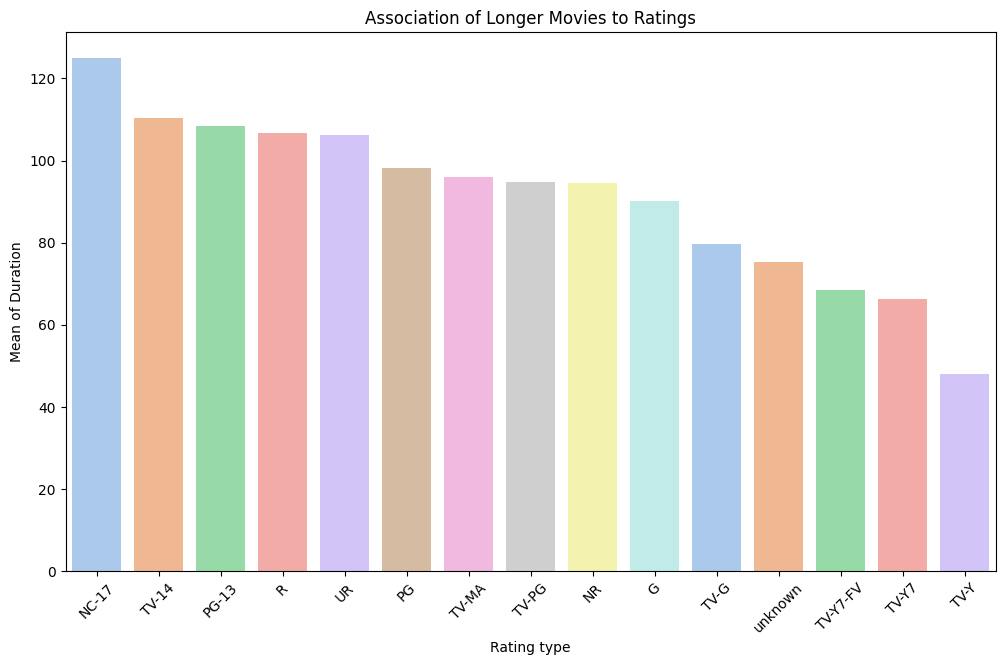

In [76]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=rating_duration,
    x='rating',
    y='duration_int',
    hue='rating',
    palette='pastel'
)

plt.title('Association of Longer Movies to Ratings')

plt.xlabel('Rating type')
plt.ylabel('Mean of Duration')

plt.xticks(rotation=45)

plt.show()

#### insights

**Movies with mature ratings such as TV-MA and R tend to have longer average durations compared to family-oriented ratings, suggesting that adult-focused content often involves more complex storytelling.**

In [77]:
# Do different countries prefer different genres?

# 1. explode the listed_in column
genre_df = df.explode('listed_in')

# 2. explode the country columns
country_exploded_df = genre_df.explode('country')

# 3. Removing unknown countries
country_df = country_exploded_df[country_exploded_df['country'] != 'unknown']

# 4. remove blank countries
country_df = country_df[country_df['country'] != '']

# 5. using grouby to categorize
preference = country_df.groupby(
    ['country','listed_in']).size().reset_index(name='count')

# 6. Create pivot table for heatmap
heatmap_data = preference.pivot(
    index='country',
    columns='listed_in',
    values='count'
)

# 7. Fill missing values
heatmap_data = heatmap_data.fillna(0)

# 8. Select top countries for readability
top_countries = country_df['country'].value_counts().head(10).index

heatmap_data = heatmap_data.loc[top_countries]

heatmap_data

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
country,,,,,,,,,,,,,,,,,,,,,
United States,404.0,7.0,18.0,24.0,390.0,17.0,81.0,680.0,145.0,52.0,...,94.0,258.0,232.0,37.0,51.0,60.0,4.0,27.0,33.0,292.0
India,137.0,0.0,0.0,3.0,26.0,0.0,11.0,323.0,9.0,5.0,...,5.0,26.0,28.0,7.0,2.0,3.0,3.0,3.0,1.0,92.0
United Kingdom,84.0,0.0,0.0,225.0,46.0,7.0,16.0,91.0,48.0,7.0,...,9.0,44.0,36.0,2.0,2.0,4.0,0.0,2.0,0.0,61.0
France,37.0,0.0,0.0,2.0,23.0,0.0,6.0,51.0,23.0,2.0,...,6.0,24.0,27.0,3.0,2.0,1.0,0.0,3.0,0.0,44.0
Canada,44.0,0.0,2.0,3.0,80.0,4.0,0.0,94.0,15.0,6.0,...,12.0,30.0,32.0,8.0,9.0,9.0,0.0,5.0,2.0,49.0
Japan,57.0,61.0,143.0,1.0,19.0,0.0,3.0,9.0,16.0,1.0,...,5.0,10.0,21.0,5.0,4.0,0.0,1.0,6.0,14.0,5.0
South Korea,17.0,0.0,0.0,0.0,10.0,0.0,0.0,17.0,24.0,1.0,...,9.0,19.0,38.0,3.0,3.0,0.0,0.0,1.0,0.0,14.0
Spain,10.0,0.0,1.0,5.0,9.0,0.0,1.0,47.0,27.0,0.0,...,4.0,5.0,11.0,0.0,0.0,0.0,0.0,0.0,1.0,38.0
Germany,33.0,0.0,0.0,6.0,17.0,0.0,0.0,42.0,15.0,4.0,...,2.0,5.0,19.0,0.0,2.0,1.0,0.0,0.0,0.0,28.0


#### visualization

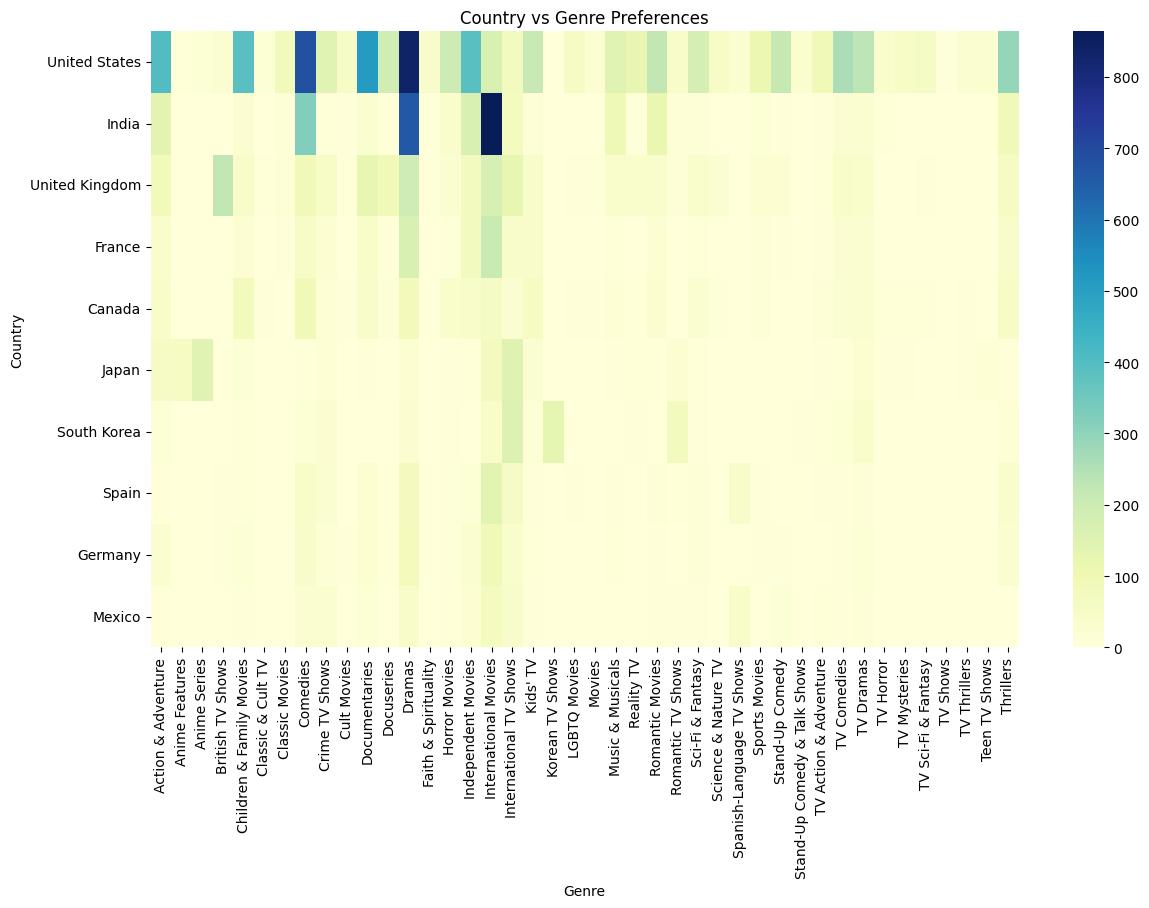

In [78]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title('Country vs Genre Preferences')

plt.xlabel('Genre')
plt.ylabel('Country')

plt.show()

#### Insight

**Different countries show varying genre preferences, with some countries strongly favoring Dramas and International Movies, indicating regional differences in audience interests and cultural content demand.**

---

### Ranking Analysis
1. Which actors appear most frequently on Netflix?
2. Which directors have the highest number of titles?
3. What are the longest movies available on Netflix?

In [79]:
# 1. Which actors appear most frequently on Netflix?

# 1. explode the 'cast' column
cast_df = df.explode('cast')

# 2. Remove the Not Available
cast_df = cast_df[cast_df['cast'] != 'Not Available']

# 3. Count actor occurence
actor_counts = cast_df['cast'].value_counts()

# 4. convert to dataframe
top_actors = actor_counts.reset_index()

# 5. Rename the columns
top_actors.columns = ['Actor', 'Count']

# 6. Show top actor
top_actors.head(10)

,Actor,Count
0,Anupam Kher,43
1,Shah Rukh Khan,35
2,Julie Tejwani,33
3,Naseeruddin Shah,32
4,Takahiro Sakurai,32
5,Rupa Bhimani,31
6,Akshay Kumar,30
7,Om Puri,30
8,Yuki Kaji,29
9,Amitabh Bachchan,28


#### Visualization

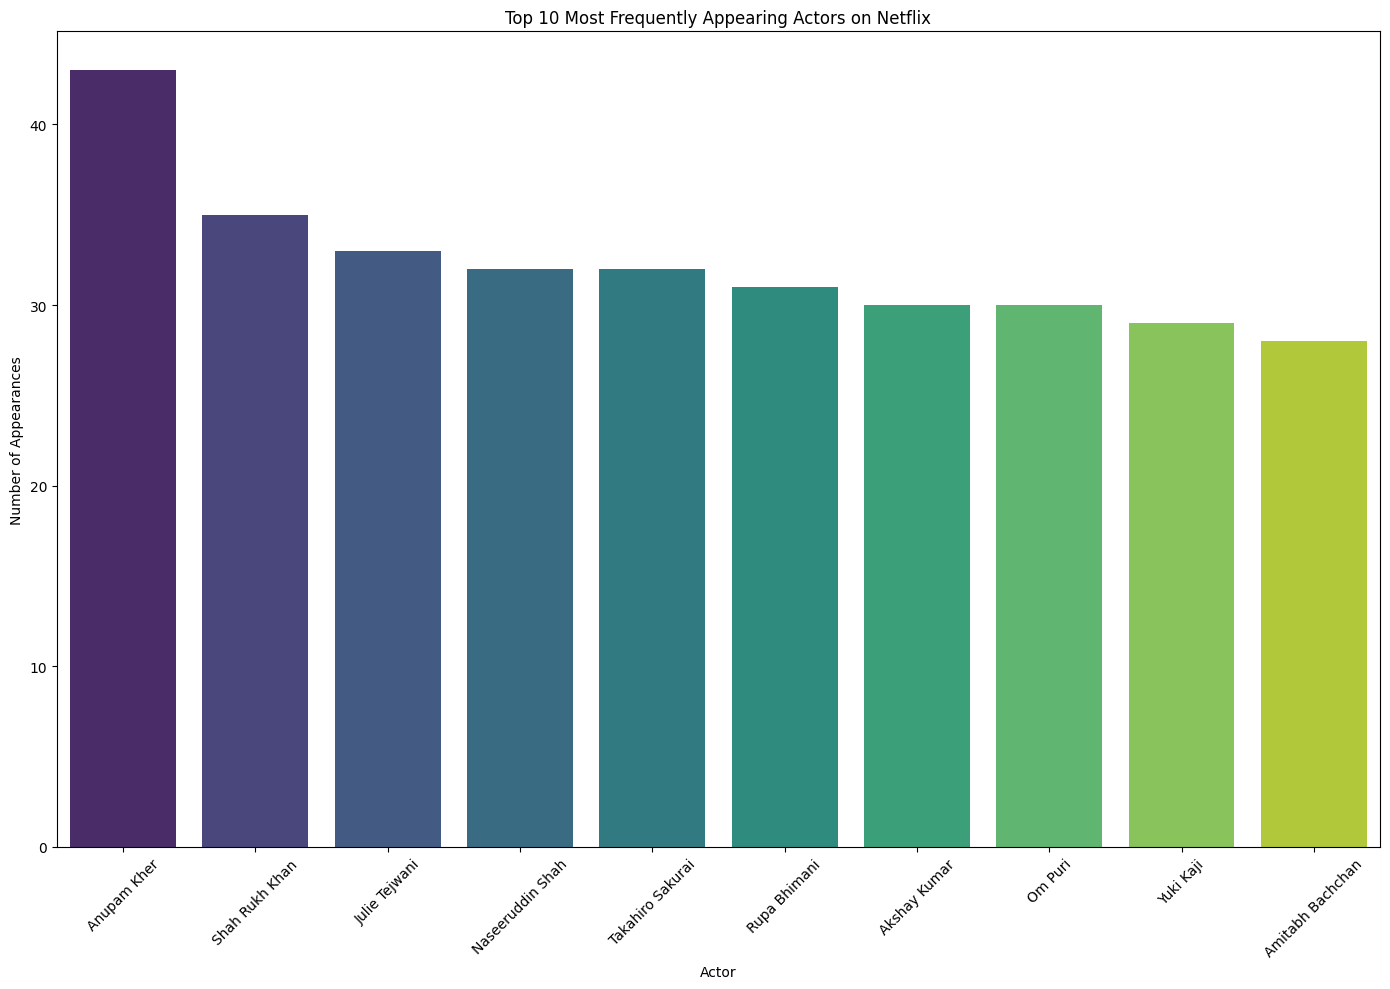

In [80]:
top_10_actors = top_actors.head(10)

# Plot
plt.figure(figsize=(14,10))

sns.barplot(
    data=top_10_actors,
    x='Actor',
    y='Count',
    hue='Actor',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Most Frequently Appearing Actors on Netflix')

plt.ylabel('Number of Appearances')
plt.xlabel('Actor')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Insights

**Anupam Kher appeared most frequently in Netflix titles, indicating his strong presence and popularity across the platform’s content library.**

In [81]:
# 2. Which directors have the highest number of titles?

# 1. explode 'director' columns
director_df = df.explode('director')

# 2. Remove the 'unknown'
director_df = director_df[director_df['director'] != 'unknown']

# 3. count directors
top_directors = director_df['director'].value_counts()

# 4. convert to dataframe

top_directors = top_directors.reset_index()

top_directors.columns = ['Director','Title Count']

top_directors.head(10)


,Director,Title Count
0,Rajiv Chilaka,19
1,"Raúl Campos, Jan Suter",18
2,Suhas Kadav,16
3,Marcus Raboy,16
4,Jay Karas,14
5,Cathy Garcia-Molina,13
6,Youssef Chahine,12
7,Martin Scorsese,12
8,Jay Chapman,12
9,Steven Spielberg,11


#### Visualization

C:\Users\amirt\AppData\Local\Temp\ipykernel_2080\4147382087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


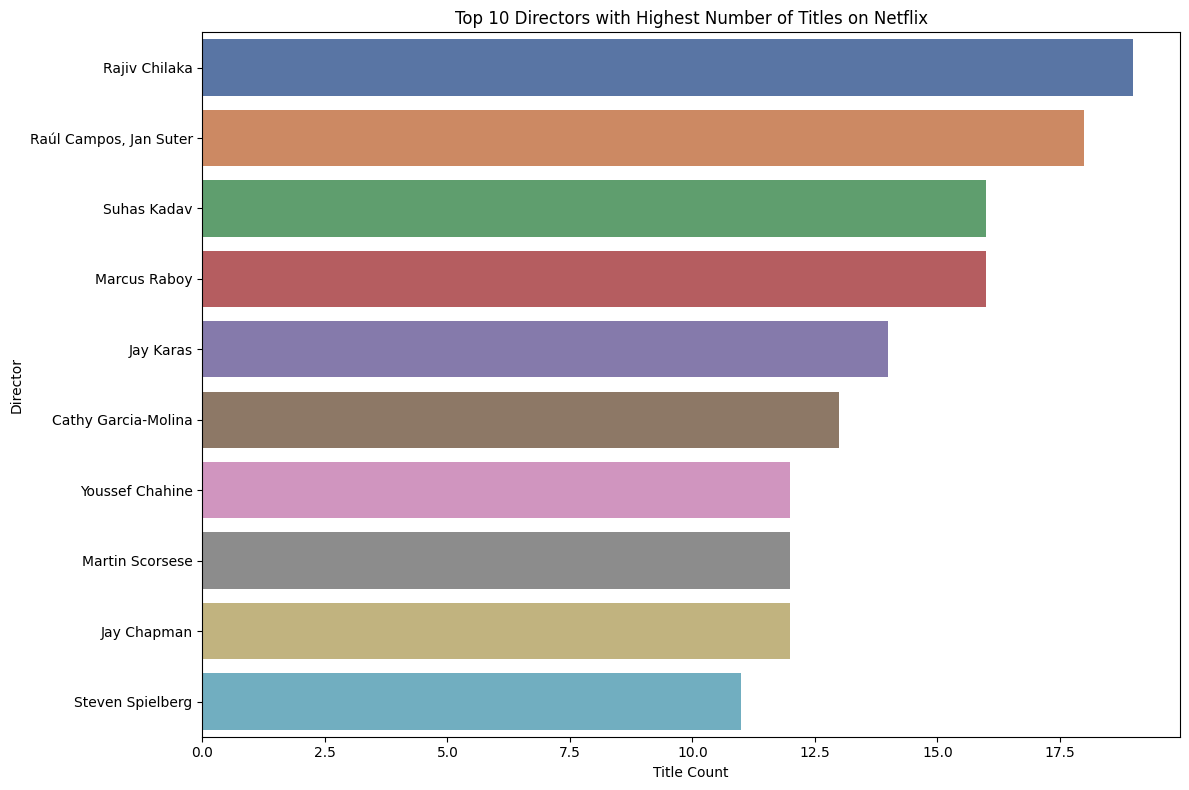

In [82]:
# Top 10 directors
top_10_directors = top_directors.head(10)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_10_directors,
    x='Title Count',
    y='Director',
    palette='deep'
)

plt.title('Top 10 Directors with Highest Number of Titles on Netflix')

plt.xlabel('Title Count')
plt.ylabel('Director')

plt.tight_layout()
plt.show()

#### Insights

**Rajiv Chilaka directed most number of titles on Netflix content , indicating his strong presence and popularity across the platform’s content library.**

In [104]:
# 3. What are the longest movies available on Netflix?
movie_df = df[df['type'] == 'Movie']

longest_movies = movie_df.sort_values(
    by='duration_int',
    ascending=False
)

longest_movies = longest_movies[
    ['title', 'duration_int', 'rating', 'release_year']
]

longest_movies = longest_movies.head(10)
longest_movies

,title,duration_int,rating,release_year
4253,Black Mirror: Bandersnatch,312.0,TV-MA,2018
717,Headspace: Unwind Your Mind,273.0,TV-G,2021
2491,The School of Mischief,253.0,TV-14,1973
2487,No Longer kids,237.0,TV-14,1979
2484,Lock Your Girls In,233.0,TV-PG,1982
2488,Raya and Sakina,230.0,TV-14,1984
166,Once Upon a Time in America,229.0,R,1984
7932,Sangam,228.0,TV-14,1964
1019,Lagaan,224.0,PG,2001
4573,Jodhaa Akbar,214.0,TV-14,2008


#### Visualization

C:\Users\amirt\AppData\Local\Temp\ipykernel_2080\419526441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


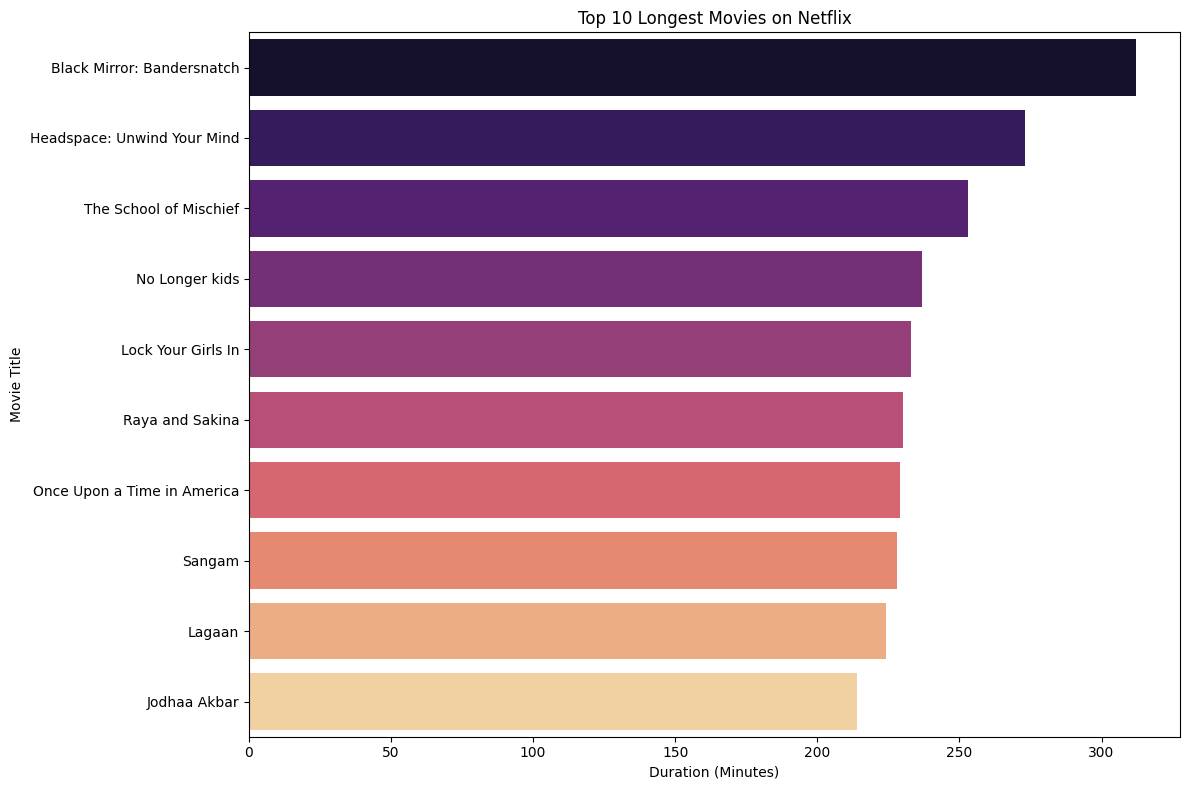

In [116]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=longest_movies,
    x='duration_int',
    y='title',
    palette='magma'
)

plt.title('Top 10 Longest Movies on Netflix')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Movie Title')

plt.tight_layout()
plt.show()

#### Insights

**The longest movies on Netflix are significantly above the average movie runtime, reflecting the availability of epic and feature-length productions on the platform.**

---

### Business Insights Analysis
1. What type of content dominates Netflix’s catalog?
2. How international is Netflix’s content library?
3. What audience group does Netflix primarily target based on ratings?
4. Which genres appear to be Netflix’s primary focus?

In [85]:
# What type of content dominates Netflix’s catalog?

content_dominance = df['type'].value_counts()

content_percentage = round(
    (content_dominance / len(df)) * 100,
    2
)

content_strategy = pd.DataFrame({
    'Count': content_dominance,
    'Percentage': content_percentage
})

content_strategy

,Count,Percentage
type,,
Movie,6131,69.62
TV Show,2676,30.38


#### Visualization

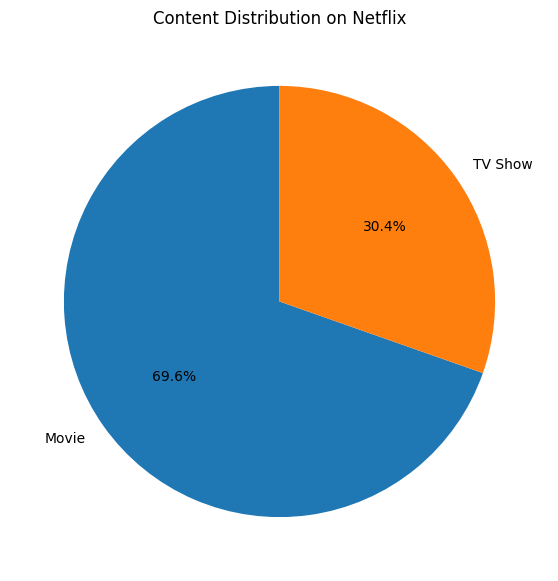

In [86]:
plt.figure(figsize=(7,7))


plt.pie(
    content_strategy['Count'],
    labels=content_strategy.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Content Distribution on Netflix')

plt.show()

#### Insights

**The analysis indicates that Netflix primarily focuses on movie content, while TV Shows represent a smaller portion of the platform’s library.**

In [87]:
# How international is Netflix’s content library?

# Explode country column
country_df = df.explode('country')

# Remove unknown countries
country_df = country_df[
    country_df['country'] != 'unknown'
]

# Remove blank countries
country_df = country_df[
    country_df['country'] != ''
]

# Number of unique countries
unique_countries = country_df['country'].nunique()

print("Number of countries:", unique_countries)

# Top contributing countries
top_countries = country_df['country'].value_counts().head(10)

top_countries

Number of countries: 122


country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

#### Visualization

C:\Users\amirt\AppData\Local\Temp\ipykernel_2080\984268438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


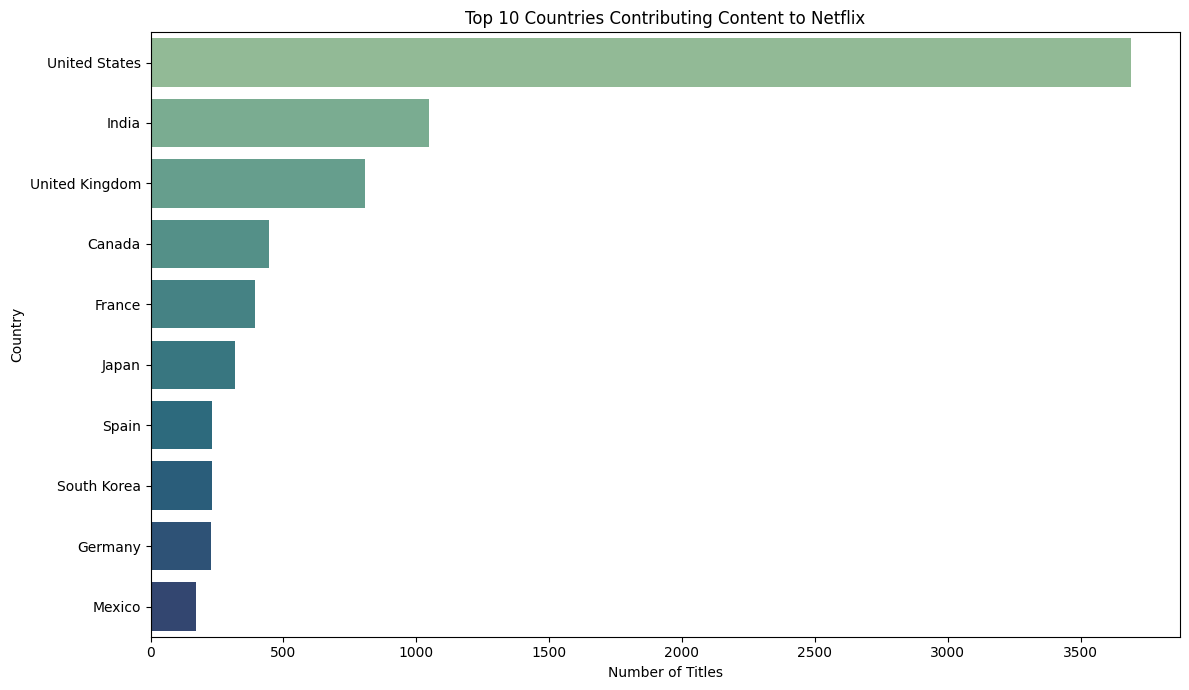

In [88]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='crest'
)

plt.title('Top 10 Countries Contributing Content to Netflix')

plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

#### Insight

**Netflix hosts content from a wide range of countries, demonstrating its strong international presence and global content strategy.**

In [89]:
# What audience group does Netflix primarily target based on ratings?

rating_distribution = df['rating'].value_counts()


rating_percentage = round(
    (rating_distribution / len(df)) * 100,
    2
)

rating_df = pd.DataFrame({
    'Count': rating_distribution,
    'Percentage': rating_percentage
})

rating_df

,Count,Percentage
rating,,
TV-MA,3207,36.41
TV-14,2160,24.53
TV-PG,863,9.80
R,799,9.07
PG-13,490,5.56
TV-Y7,334,3.79
TV-Y,307,3.49
PG,287,3.26
TV-G,220,2.50


#### Visualization

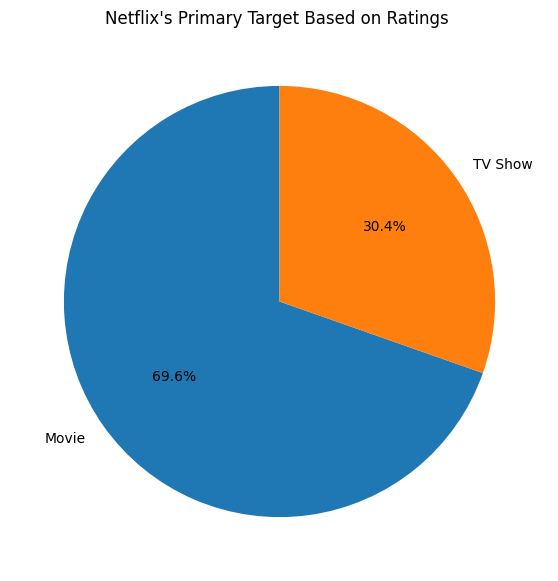

In [90]:
plt.figure(figsize=(7,7))

plt.pie(
    content_strategy['Count'],
    labels=content_strategy.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Netflix\'s Primary Target Based on Ratings ')

plt.show()

#### Insight

**Since TV-MA dominates Netflix’s content ratings, the platform appears to focus heavily on adult-oriented entertainment, including mature themes, violence, and strong language.**

In [108]:
# Which genres appear to be Netflix’s primary focus?

# Explode genres
genre_df = df.explode('listed_in')

# Count genre frequency
genre_counts = genre_df['listed_in'].value_counts()

# Convert to dataframe
genre_focus = genre_counts.reset_index()

# Rename columns
genre_focus.columns = ['Genre', 'Frequency']

# Show top genres
genre_focus = genre_focus.head(10)
genre_focus

,Genre,Frequency
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


#### Visualization

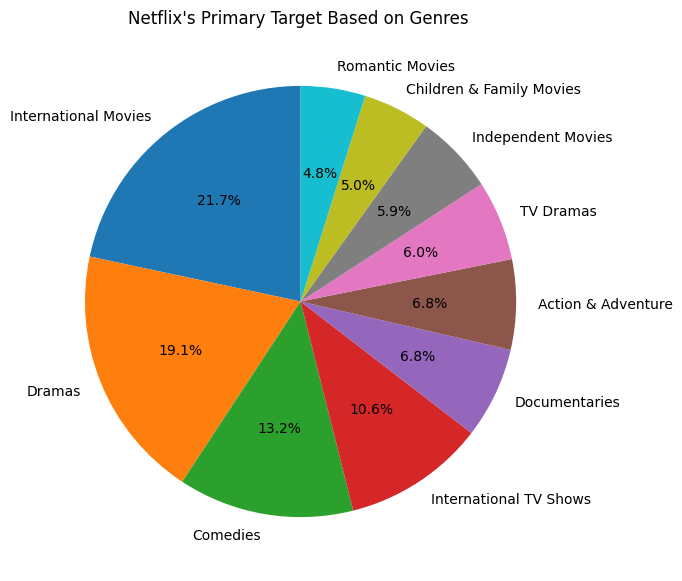

In [113]:
plt.figure(figsize=(7,7))

plt.pie(
    genre_focus['Frequency'],
    labels=genre_focus['Genre'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Netflix\'s Primary Target Based on Genres ')

plt.show()

#### Insight

**Netflix primarily focuses on International Movies, Dramas, and Comedies, highlighting its emphasis on globally appealing and entertainment-focused content.**

---

### Anomaly Analysis
1. Are there unusually long or short movies in the dataset?
2. Were there years with unusually high content additions?

In [93]:
# Are there unusually long or short movies in the dataset?

# 1. Filter Movies
movie_df = df[df['type'] == 'Movie']

# 2. Statistical Summary
movie_df['duration_int'].describe()

# 3.Dind Extremely Long Movies

long_movies = movie_df[
    movie_df['duration_int'] > 200
]

long_movies[['title','duration_int']]

# 4. Find Extremely short movies

short_movies = movie_df[
    movie_df['duration_int'] < 50
]

short_movies[['title','duration_int']]

,title,duration_int
45,My Heroes Were Cowboys,23.0
71,A StoryBots Space Adventure,13.0
77,Little Singham - Black Shadow,48.0
470,Bridgerton - The Afterparty,39.0
484,Lee Su-geun: The Sense Coach,46.0
...,...,...
8587,Thunderbolt,42.0
8657,Under an Arctic Sky,40.0
8707,"We, the Marines",38.0
8759,World's Weirdest Homes,49.0


In [94]:
# Better Approach using IQR

Q1 = movie_df['duration_int'].quantile(0.25)

Q3 = movie_df['duration_int'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = movie_df[
    (movie_df['duration_int'] < lower_bound) |
    (movie_df['duration_int'] > upper_bound)
]

outliers[['title', 'duration_int']]


,title,duration_int
22,Avvai Shanmughi,161.0
24,Jeans,166.0
45,My Heroes Were Cowboys,23.0
71,A StoryBots Space Adventure,13.0
73,King of Boys,182.0
...,...,...
8763,WWII: Report from the Aleutians,45.0
8764,Wyatt Earp,191.0
8770,Yaadein,171.0
8788,You Carry Me,157.0


#### Visualization

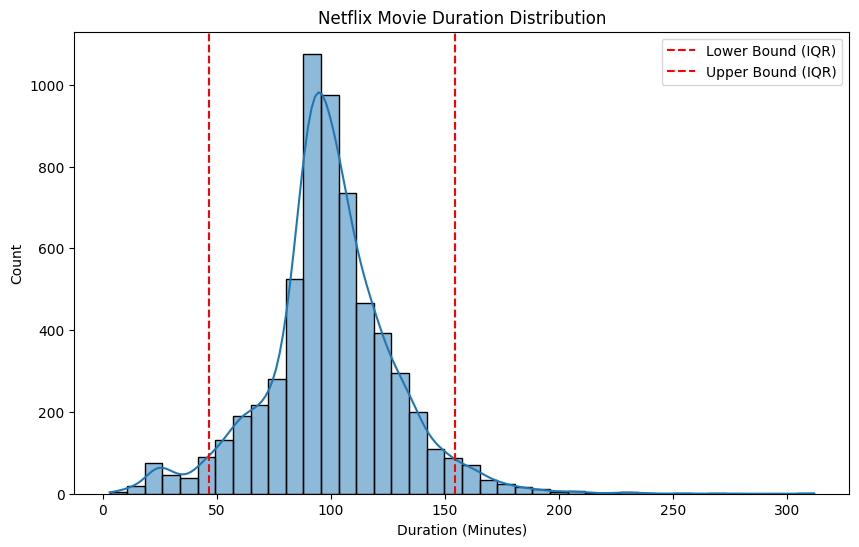

In [114]:
plt.figure(figsize=(10, 6))

sns.histplot(movie_df['duration_int'], bins=40, kde=True)

plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound (IQR)')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound (IQR)')

plt.title('Netflix Movie Duration Distribution')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Count')

plt.legend()
plt.show()

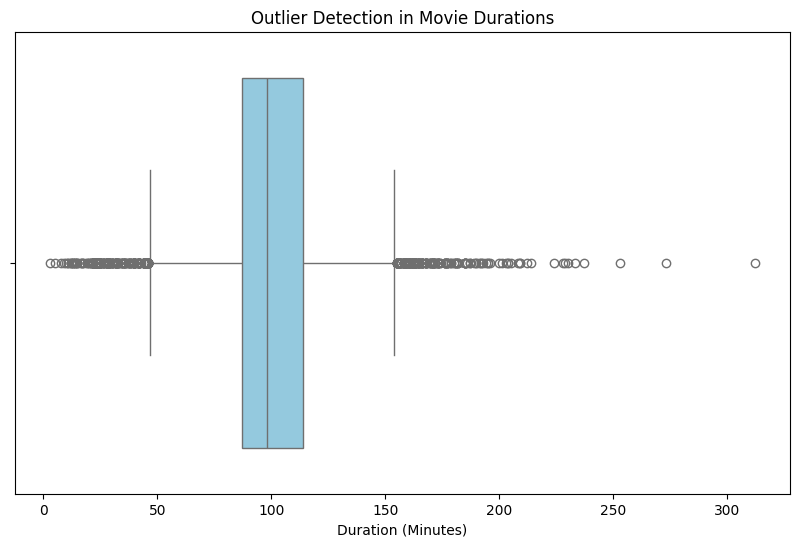

In [96]:
# Box plot


plt.figure(figsize=(10,6))

sns.boxplot(
    x=movie_df['duration_int'],
    color='skyblue'
)

plt.title('Outlier Detection in Movie Durations')

plt.xlabel('Duration (Minutes)')

plt.show()

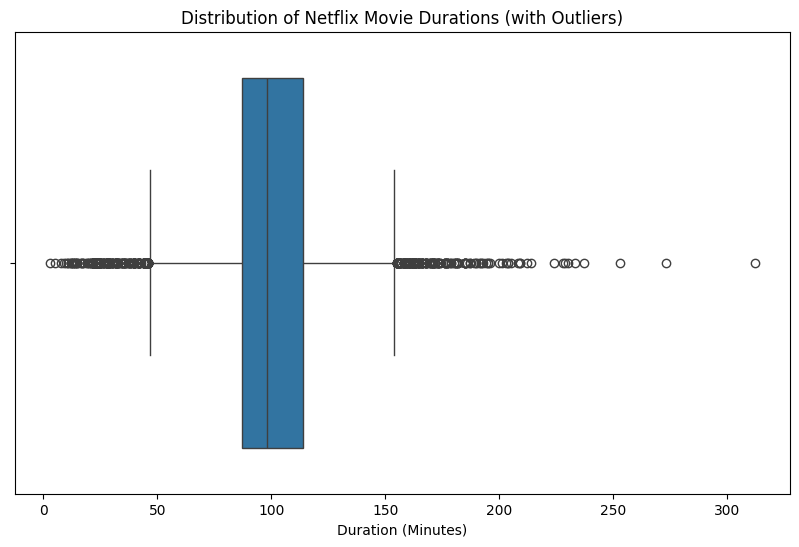

In [115]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=movie_df,
    x='duration_int'
)

plt.title('Distribution of Netflix Movie Durations (with Outliers)')
plt.xlabel('Duration (Minutes)')

plt.show()

#### Insight

**Most Netflix movies fall within a standard duration range, while a small number of titles appear as outliers due to significantly longer runtimes.**

In [97]:
# 2. Were there years with unusually high content additions?

year_growth = df['year_added'].value_counts().sort_index()

year_growth

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: Int64

In [98]:
year_growth = year_growth.reset_index()

year_growth.columns = ['Year', 'Count']

In [99]:
mean_growth = year_growth['Count'].mean()

std_growth = year_growth['Count'].std()

In [100]:
unusual_years = year_growth[
    year_growth['Count'] > mean_growth + std_growth
]

unusual_years

,Year,Count
10,2018,1625
11,2019,1999
12,2020,1878
13,2021,1498


#### Visualization

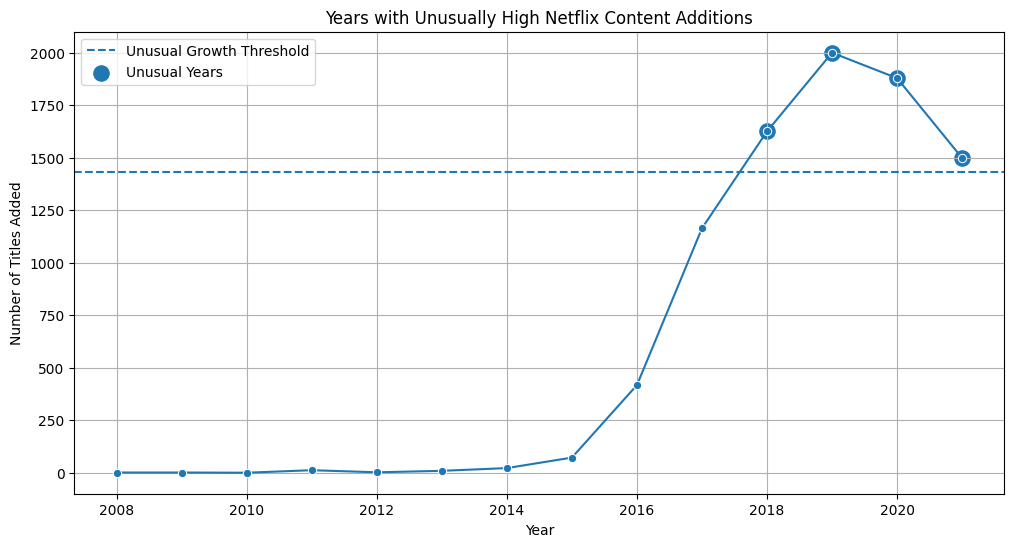

In [101]:
threshold = mean_growth + std_growth

plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_growth,
    x='Year',
    y='Count',
    marker='o'
)

# Threshold line
plt.axhline(
    y=threshold,
    linestyle='--',
    label='Unusual Growth Threshold'
)

# Highlight unusual years
plt.scatter(
    unusual_years['Year'],
    unusual_years['Count'],
    s=120,
    label='Unusual Years'
)

plt.title('Years with Unusually High Netflix Content Additions')

plt.xlabel('Year')
plt.ylabel('Number of Titles Added')

plt.legend()

plt.grid(True)

plt.show()

#### Insight

**A few years recorded significantly higher-than-average title additions, highlighting Netflix’s accelerated content growth phase.**

---

## Final Insight Conclusion 

Netflix’s content library is dominated by Movies compared to TV Shows, showing an initial focus on providing a large volume of easily consumable content. However, TV Shows play an important role in improving user engagement and retention through binge-watching formats.

Most movies fall within a standard duration range (around 80–120 minutes), indicating that Netflix mainly follows industry norms. The platform also focuses on a few key genres such as drama, comedy, and international content, reflecting a global and diverse content strategy.

Overall, Netflix uses Movies to attract users and TV Shows to retain them, balancing both content volume and long-term viewer engagement.